In [1]:
# point to GPU
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-37e6e660-d7d1-52e9-9f59-d3fa20a33989"

In [18]:
import numpy as np
import pandas as pd
import torch
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm
import gzip

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import sys
sys.path.append("../2_train_models")
from file_configs import FoldFilesConfig, MergedFilesConfig
from data_loading import extract_observed_profiles, extract_sequences, one_hot_encode

sys.path.append("../3_eval_models")
from eval_utils import model_predict_with_rc

sys.path.append("../figure_notebooks")
from load_annotations_utils import load_coords_with_summits
from common_functions import load_coords

import logomaker

In [3]:
# specify what set of procapnet models to look at
cell_type = "K562"

# the unique IDs for each of the folds / models in this cell type
timestamps = ["2023-05-29_15-51-40",
              "2023-05-29_15-58-41",
              "2023-05-29_15-59-09",
              "2023-05-30_01-40-06",
              "2023-05-29_23-21-23",
              "2023-05-29_23-23-45",
              "2023-05-29_23-24-11"]

# these usually don't change
model_type = "strand_merged_umap"
data_type = "procap"

# size of the model inputs and outputs
in_window = 2114
out_window = 1000

In [4]:
# Load the config object for when model outputs were merged across all folds
# (just to pull some filepaths from)

merged_config = MergedFilesConfig(cell_type, model_type, data_type)

# these paths aren't specific to any model / fold, cell type, or data_type

proj_dir = merged_config.proj_dir
genome_path = merged_config.genome_path
chrom_sizes = merged_config.chrom_sizes

figures_dir = proj_dir + "figures_final/"
os.makedirs(figures_dir, exist_ok=True)

## Load Data, Models

In [5]:
# for ProCapNet, load in:
# 1) coordinates for all PRO-cap peaks in K562 (for plot annotation)
# 1) measured PRO-cap profiles in K562
# 2) predicted PRO-cap profiles + counts in K562


import numpy as np
import pandas as pd
import os
import torch
from collections import defaultdict
from scipy.spatial.distance import jensenshannon

from tqdm import tqdm

import matplotlib.pyplot as plt

import sys
sys.path.append("../2_train_models")
from file_configs import FoldFilesConfig, MergedFilesConfig
from data_loading import extract_peaks, extract_observed_profiles, extract_sequences
from data_loading import read_fasta_fast

sys.path.append("../figure_notebooks")
from load_annotations_utils import load_coords_with_summits
from common_functions import load_coords


def load_fold_configs(cell_type, timestamps,
                      model_type = "strand_merged_umap", data_type = "procap"):
    
    # Load the config objects (filepaths holders) for each fold a model was trained on

    fold_configs = []
    for fold_i, timestamp in enumerate(timestamps):
        # folds are 1-indexed, and config constructor is expecting a string
        fold = str(fold_i + 1)
        
        # load the config object for this specific fold / model
        config = FoldFilesConfig(cell_type, model_type, fold, timestamp, data_type)
        fold_configs.append(config)
        
    return fold_configs

def get_pseudorep_filepaths(pseudorep, pos_or_neg, data_dir):
    # Get paths to bigwigs for the pseudoreplicates of an experiment
    #  - pseudorep should be either an int (1-indexed) or an integer string
    
    assert pos_or_neg in ["pos", "neg"], pos_or_neg
    return os.path.join(data_dir, "pseudorep" + str(pseudorep) + "." + pos_or_neg + ".bigWig")


def load_pseudoreplicate_profiles(pseudorep, peaks_path, data_dir, out_window=1000):
    pos_bw_path = get_pseudorep_filepaths(pseudorep, "pos", data_dir)
    neg_bw_path = get_pseudorep_filepaths(pseudorep, "neg", data_dir)
    
    profs = extract_observed_profiles(pos_bw_path, neg_bw_path, peaks_path,
                                      out_window=out_window, verbose=True)
    return profs


def get_sort_order_test_sets(merged_config, timestamps, in_window=2114, cell_type="K562"):
    # Each model / fold has a mutually exclusive test set; the order of the examples
    # in each test set differs from the order in the merged file of all examples.
    # So, this function figures out how to reorder the test set model predictions
    # so that they can be compared to the observed data.
    
    # First, load in the test set coordinates for each fold's test set
    fold_configs = load_fold_configs(cell_type, timestamps)
    
    test_coords = []
    for config in fold_configs:
        test_coords.extend(load_coords(config.test_peak_path, in_window))
        
    # Second, load in the test set coordinates for the merged file
    # (the "correct order")
    
    all_coords = load_coords(merged_config.all_peak_path, in_window)
    
    # Third, figure out the re-ordering needed to arrange the test coords
    # so they match the ordering in the merged file.
    # (then use that ordering later to fix the order of model predictions)
    
    sort_order = [test_coords.index(coord) for coord in all_coords]
    assert np.all(np.array(all_coords) == np.array(test_coords)[sort_order])
    
    return sort_order


def load_procapnet_test_data(merged_config, timestamps, cell_type="K562", out_window=1000):
    true_profs = []
    pseudorep1_profs = []
    pseudorep2_profs = []
    log_pred_profs = []
    pred_logcounts = []
    
    fold_configs = load_fold_configs(cell_type, timestamps)
    
    for config in fold_configs:
        # Load observed data: replicate-merged PRO-cap signal
        obs_profs = extract_observed_profiles(config.plus_bw_path,
                                              config.minus_bw_path,
                                              config.test_peak_path,
                                              out_window=out_window,
                                              verbose=False)
        true_profs.extend(obs_profs)

        # Load PRO-cap signal for each pseudoreplicate individually (to see reproducibility)
        pseudorep1_profs.extend(load_pseudoreplicate_profiles(1, config.test_peak_path, config.data_dir))
        pseudorep2_profs.extend(load_pseudoreplicate_profiles(2, config.test_peak_path, config.data_dir))

        # Load model predictions
        log_pred_profs.extend(np.load(config.pred_profiles_test_path))
        pred_logcounts.extend(np.load(config.pred_logcounts_test_path).squeeze())
        
        # everything above should have loaded in the same number of examples/loci
        
        assert len(pseudorep1_profs) == len(pseudorep2_profs)
        assert len(pseudorep1_profs) == len(true_profs)
        assert len(log_pred_profs) == len(pred_logcounts)
        assert len(pred_logcounts) == len(true_profs)
        
    sort_order = get_sort_order_test_sets(merged_config, timestamps)
    
    true_profs = np.array(true_profs)[sort_order]
    pseudorep1_profs = np.array(pseudorep1_profs)[sort_order]
    pseudorep2_profs = np.array(pseudorep2_profs)[sort_order]
    log_pred_profs = np.array(log_pred_profs)[sort_order]
    pred_logcounts = np.array(pred_logcounts)[sort_order]
    
    pred_profs = np.exp(log_pred_profs)
    
    return true_profs, pseudorep1_profs, pseudorep2_profs, pred_profs, pred_logcounts



coords = load_coords(merged_config.all_peak_path, in_window=in_window)

K562_true_profs, _, _, K562_procapnet_pred_profs, K562_procapnet_pred_logcounts = load_procapnet_test_data(merged_config,
                                                                                                           timestamps)

Timestamp: 2023-05-29_15-51-40
Timestamp: 2023-05-29_15-58-41
Timestamp: 2023-05-29_15-59-09
Timestamp: 2023-05-30_01-40-06
Timestamp: 2023-05-29_23-21-23
Timestamp: 2023-05-29_23-23-45
Timestamp: 2023-05-29_23-24-11
== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold1_test.bed.gz
Profile length: 1000
Num. Examples: 4334


Loading Profiles: 4334it [00:00, 4839.70it/s]


== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold1_test.bed.gz
Profile length: 1000
Num. Examples: 4334


Loading Profiles: 4334it [00:00, 4802.60it/s]


== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold1_test.bed.gz
Profile length: 1000
Num. Examples: 4334
== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold2_test.bed.gz
Profile length: 1000
Num. Examples: 3699


...

Loading Profiles: 4347it [00:00, 5515.65it/s]

== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold7_test.bed.gz
Profile length: 1000
Num. Examples: 4347



Loading Profiles: 4347it [00:00, 5522.44it/s]

== In Extract Profiles ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks_fold7_test.bed.gz
Profile length: 1000
Num. Examples: 4347


Timestamp: 2023-05-29_15-51-40
Timestamp: 2023-05-29_15-58-41
Timestamp: 2023-05-29_15-59-09
Timestamp: 2023-05-30_01-40-06
Timestamp: 2023-05-29_23-21-23
Timestamp: 2023-05-29_23-23-45
Timestamp: 2023-05-29_23-24-11


### Load ProCapNet

In [6]:
# we'll just use the first-fold model for now

fold_config = FoldFilesConfig(cell_type, model_type, fold="1", timestamp = timestamps[0])
model_path = fold_config.model_save_path

procapnet = torch.load(model_path)
procapnet = procapnet.eval()
procapnet = procapnet.cuda()

Timestamp: 2023-05-29_15-51-40


/tmp/ipykernel_1723432/1062985650.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  procapnet = torch.load(model_path)


### ISM

In [15]:
pred_prof_puffin = np.load("pred_prof_puffin_example.npy")
ism_puffin = np.load("ism_puffin_example.npy")

In [10]:
# tangermeme!!! from Jacob, https://github.com/jmschrei/tangermeme
from tangermeme.ism import saturation_mutagenesis
from tangermeme.utils import one_hot_encode as tangermeme_ohe


def load_sequence_at_locus(coord, genome_path):
    chrom, start, end = coord
    
    # load (forward strand) genomic sequence between start and end coords
    genome = read_fasta_fast(genome_path, include_chroms = [chrom])
    # seq is a string
    seq = genome[chrom][start:end]
    
    # one-hot encode the sequence string (returns numpy array)
    onehot_seq = one_hot_encode(seq).T
    
    # after transposing, onehot_seq is shape (4, end - start)
    return seq, onehot_seq

In [11]:
class ProCapNetISMWrapper(torch.nn.Module):
    # tangermeme needs a model-wrapper to do ISM with -- this one is for ProCapNet
    
    def __init__(self, model):
        super(ProCapNetISMWrapper, self).__init__()
        self.model = model

    def logits_to_a_number_deepshappy(self, logits):
        # more complicated way of collapsing a profile prediction to just one scalar;
        # I tried this and the easier way below, results were qualitatively the same
        logits = torch.Tensor(logits).reshape(-1)
        mean_norm_logits = logits - torch.mean(logits, axis = -1, keepdims = True)
        softmax_probs = torch.nn.Softmax(dim=-1)(mean_norm_logits.detach())
        final = (mean_norm_logits * softmax_probs).sum(axis=-1)
        return final
    
    def logits_to_a_number(self, logits):
        # simplest way of collapsing a profile prediction to just one scalar
        pred = np.exp(logits)
        final = pred.sum()
        return final
        
    def forward_one_seq(self, seq):
        # make a model prediction, collapse to one number
        pred_prof = self.model(seq[None,...])[0].cpu().numpy()
        return self.logits_to_a_number(pred_prof)
        
    def forward(self, X):
        # make model predictions + collapse to 1 number per example
        model_outputs = [self.forward_one_seq(seq) for seq in X]
        return torch.Tensor(np.array(model_outputs))


def get_procapnet_ism(seq_onehot, model):
    assert seq_onehot.shape[-2] == 4, seq_onehot.shape
    seq_len = seq_onehot.shape[-1]

    wrapper = ProCapNetISMWrapper(model)
    
    # the start and end here are hard-coded for the example I wanted to plot
    # (they let you just do ISM on the bases you're going to plot)
    
    X_attr = saturation_mutagenesis(wrapper, seq_onehot.squeeze()[None,...],
                                    start = seq_len//2 - 100, end = seq_len//2 + 250,
                                    device='cuda', verbose=True)
    return X_attr

In [12]:
locus_i = 20938
_, seq_onehot = load_sequence_at_locus(coords[locus_i], genome_path)
seq_onehot = torch.Tensor(seq_onehot)

ism_pcn = get_procapnet_ism(seq_onehot, procapnet).squeeze()

Loading genome sequence from /mnt/lab_data2/kcochran/procapnet/genomes/hg38.withrDNA.fasta


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:01<00:00, 29.80it/s]


## Plot Locus With ISM From Both Models

('chr3', 170036873, 170038987)
Puffin vs. ProCapNet at the $\it{GPR160}$ Promoter, chr3:170,037,860-170,038,180


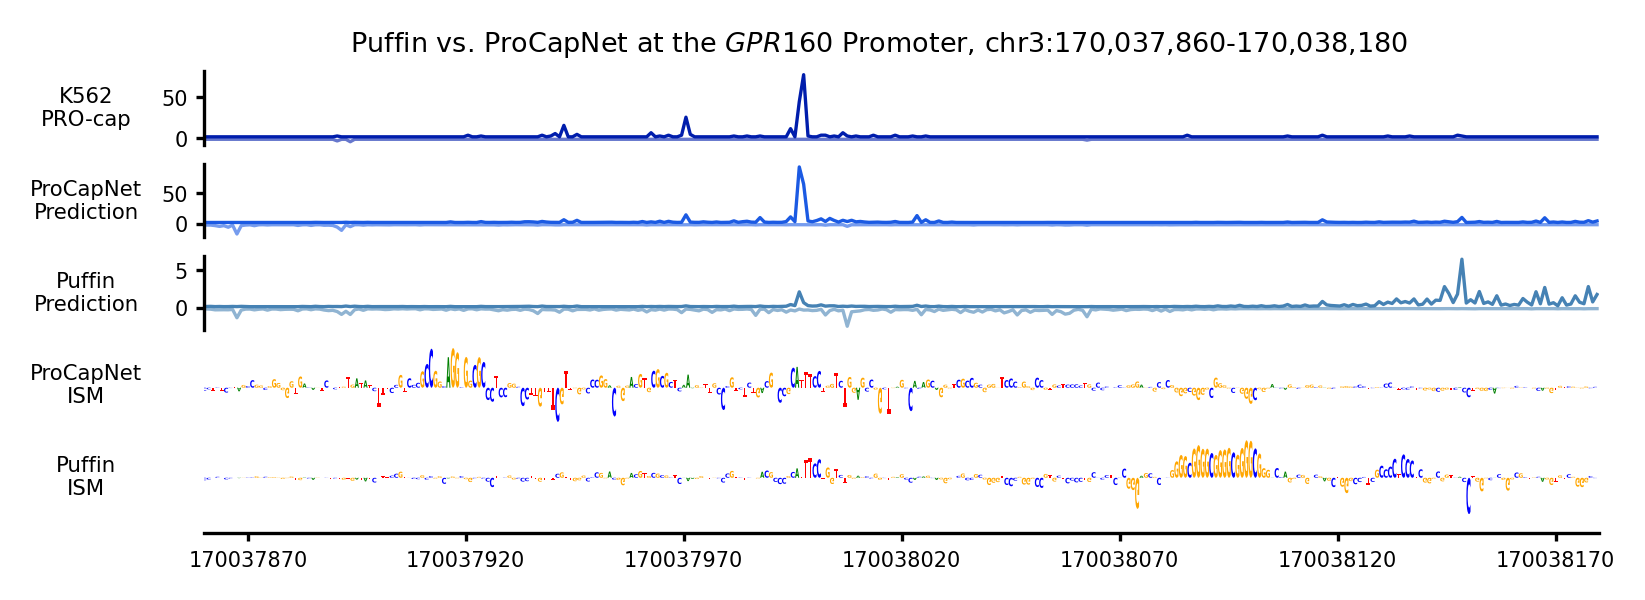

In [21]:
def plot_prof_on_ax(profile, ax, zoom_start, zoom_end,
                    color = "#001DAC", alphas = [1, 0.6],
                    linewidth=0.8, x_axis_buffer=0):
    
    # the + 0.5 is so the profiles are right on top of the bases of the scores
    x_range = np.arange(0, zoom_end -zoom_start) + 0.5
    
    # when both strands have data at 0, they'll plot on top of each other.
    # this offset is the minimum needed to uniformly add to the plotting
    # of both strands so that when the lines are at 0, they're both still visible
    offset = np.max(np.abs(profile[:, zoom_start:zoom_end])) * 0.02
    
    # plot positive strand
    ax.plot(x_range, profile[0, zoom_start:zoom_end] + offset,
            alpha = alphas[0], c = color, linewidth=linewidth)
    # plot negative strand
    ax.plot(x_range, -1 * profile[1, zoom_start:zoom_end] - offset,
            alpha = alphas[1], c = color, linewidth=linewidth)
    

def plot_motif_on_ax(array, ax):
    assert len(array.shape) == 2 and array.shape[-1] == 4, array.shape
    # reformat pwm to what logomaker expects
    df = pd.DataFrame(array, columns=['A', 'C', 'G', 'T'])
    df.index.name = 'pos'

    # plot motif ("baseline_width=0" removes the y=0 line)
    crp_logo = logomaker.Logo(df, ax=ax, font_name='Arial Rounded', baseline_width=0)
    
    # fix appearance to be less terrible
    crp_logo.style_spines(visible=False)
    ax.set_ylim(min(df.sum(axis=1).min(), 0), df.sum(axis=1).max())
    ax.set_xticks([])
    ax.set_yticks([])
    
    return crp_logo


def plot_locus(locus_i, true_prof, pcn_pred_prof, puffin_pred_prof, ism_pcn, ism_puffin,
               start = out_window//2 - 100, stop = out_window//2 + 250,
               save_path = None):
    
    print(coords[locus_i])
    chrom, genomic_start, genomic_end = coords[locus_i]
    
    
    plot_params = {"xtick.labelsize": 8, "ytick.labelsize": 8}
    plt.rcParams.update(plot_params)
    axis_fontsize = 5.1
    axis_labelpad = 18
    axis_index = 0
    
    
    height_ratios = [100,100,100,100,100, 1]
    
    
    fig = plt.figure(figsize=(6, 0.4 * 5), dpi=300)
    gs = fig.add_gridspec(5 + 1, height_ratios = height_ratios, hspace=0.3)
    axes = gs.subplots()
    
    plot_prof_on_ax(true_prof, axes[0], start, stop,
                    color = "#001DAC")

    axes[0].set_ylabel("K562\nPRO-cap", fontsize=axis_fontsize,
                       labelpad=axis_labelpad, rotation=0,
                       verticalalignment = "center")
    
    
    plot_prof_on_ax(pcn_pred_prof,
                    axes[1], start, stop,
                    color = "#1B5AE3")

    axes[1].set_ylabel("ProCapNet\nPrediction", fontsize=axis_fontsize,
                       labelpad=axis_labelpad, rotation=0,
                       verticalalignment = "center")
    
    plot_prof_on_ax(pred_prof_puffin, axes[2], start, stop,
                    color = "steelblue")

    axes[2].set_ylabel("Puffin\nPrediction", fontsize=axis_fontsize,
                       labelpad=axis_labelpad, rotation=0,
                       verticalalignment = "center")
    
    
    plot_motif_on_ax(ism_pcn.T, axes[3])
    axes[3].set_ylabel("ProCapNet\nISM", fontsize=axis_fontsize,
                       labelpad=axis_labelpad, rotation=0,
                       verticalalignment = "center")
    
    plot_motif_on_ax(ism_puffin.T, axes[4])
    axes[4].set_ylabel("Puffin\nISM", fontsize=axis_fontsize,
                       labelpad=axis_labelpad, rotation=0,
                       verticalalignment = "center")
    
    
    # the zooming-into-bases-I-wanted-to-plot I did with the ISM parameters was close,
    # but not exact, so this parameter is just me cropping a few more bases off the left
    # side of the plot to zoom in on the interesting region better
    extra_by_eye_start_offset = 30 # like for aesthetics only
    
    xticks = np.arange(0, stop - start + 1, 50) - 10   
    
    for ax_i, ax in enumerate(axes):
        ax.spines[["top", "right"]].set_visible(False)
        
        if ax_i < len(axes) - 1:
            ax.set_xticks([])
            ax.spines[["bottom"]].set_visible(False)
        else:
            ax.set_xticks(xticks, xticks + start + genomic_start + (in_window // 2 - out_window // 2))
            ax.tick_params("x", length=2, pad=2, labelsize=5)
            ax.set_yticks([])
            
        ax.tick_params("y", length=2, pad=2, labelsize=5)
        
        ax.set_xlim(0 + extra_by_eye_start_offset, stop - start)
    
    title = "Puffin vs. ProCapNet at the " + r'$\it{GPR160}$ Promoter, ' + chrom + ":"
    title += f"{genomic_start + in_window//2 + (start - out_window//2) + extra_by_eye_start_offset:,}" + "-"
    title += f"{genomic_start + in_window//2 + (stop - out_window//2):,}"
    fig.suptitle(title, y = 0.95, fontsize=6.5, horizontalalignment='center')
    
    print(title)
    fig.align_ylabels()
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', pad_inches = 0.05, dpi = 300, transparent=True)
    
    plt.show()

    
plot_locus(locus_i, K562_true_profs[locus_i],
           K562_procapnet_pred_profs[locus_i] * np.exp(K562_procapnet_pred_logcounts[locus_i]),
           pred_prof_puffin,
           ism_pcn, ism_puffin,
           save_path = figures_dir + "puffin_vs_pcn_example.pdf")